In [2]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [3]:
import zipfile, os

ZIP = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/eye-gaze.zip"
OUT = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/"

print("Unzipping... (may take 2-3 mins)")
with zipfile.ZipFile(ZIP, 'r') as z:
    z.extractall(OUT)
print("✓ Done")

Unzipping... (may take 2-3 mins)
✓ Done


In [4]:
import os

MPII = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE"

print("=== MPIIGAZE folder contents ===\n")
for item in sorted(os.listdir(MPII)):
    full = os.path.join(MPII, item)
    if os.path.isdir(full):
        # count files inside
        count = sum(len(files) for _, _, files in os.walk(full))
        print(f"  [folder]  {item}/  →  {count:,} files")
    else:
        size = os.path.getsize(full) / (1024**2)
        print(f"  [file]    {item}  →  {size:.1f} MB")

=== MPIIGAZE folder contents ===

  [folder]  MPIIGaze/  →  214,794 files
  [file]    eye-gaze.zip  →  2125.0 MB


In [5]:
MPII_ROOT = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/MPIIGaze"

print("=== MPIIGaze structure ===\n")
for item in sorted(os.listdir(MPII_ROOT)):
    full = os.path.join(MPII_ROOT, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  {item}/  →  {count} items inside")
    else:
        print(f"  {item}")

=== MPIIGaze structure ===

  6 points-based face model.mat
  Annotation Subset/  →  15 items inside
  Data/  →  2 items inside
  Evaluation Subset/  →  3 items inside
  ReadMe.txt
  changelog.txt


In [6]:
import os

DATA = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/MPIIGaze/Data"
print("=== Data folder ===\n")
for item in sorted(os.listdir(DATA)):
    full = os.path.join(DATA, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  {item}/  →  {count} items inside")
    else:
        print(f"  {item}")

=== Data folder ===

  Normalized/  →  15 items inside
  Original/  →  15 items inside


In [7]:
# confirmed path
MPI_PATH = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/MPIIGaze/Data/Original"

participants = sorted(os.listdir(MPI_PATH))
print(f"Total participants : {len(participants)}")
print(f"Participant IDs    : {participants}")

Total participants : 15
Participant IDs    : ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13', 'p14']


In [9]:
import os

MPI_PATH = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/MPIIGaze/Data/Original"

for p in sorted(os.listdir(MPI_PATH)):
    p_path = os.path.join(MPI_PATH, p)
    days = os.listdir(p_path)
    print(f"  {p} → {len(days)} items inside")


  p00 → 40 items inside
  p01 → 70 items inside
  p02 → 40 items inside
  p03 → 66 items inside
  p04 → 26 items inside
  p05 → 39 items inside
  p06 → 63 items inside
  p07 → 57 items inside
  p08 → 48 items inside
  p09 → 21 items inside
  p10 → 17 items inside
  p11 → 20 items inside
  p12 → 8 items inside
  p13 → 13 items inside
  p14 → 8 items inside


In [12]:
import os, cv2

MPI_PATH = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/MPIIGaze/Data/Original"
p00 = os.path.join(MPI_PATH, "p00")
day = [d for d in os.listdir(p00) if d != "Calibration"][0]
files = [f for f in os.listdir(os.path.join(p00, day)) if f.endswith('.jpg')]
print(f"Files found: {len(files)}")
img = cv2.imread(os.path.join(p00, day, files[0]))
print("✓ Ready!" if img is not None else "✗ Still syncing")

Files found: 995
✓ Ready!


In [18]:
import os, cv2

MPI_PATH = "/content/drive/MyDrive/EyeMotionID/data/raw/MPIIGAZE/MPIIGaze/Data/Original"

total = 0
for p in sorted(os.listdir(MPI_PATH)):
    p_path = os.path.join(MPI_PATH, p)
    for day in os.listdir(p_path):
        day_path = os.path.join(p_path, day)
        if os.path.isdir(day_path):
            total += len(os.listdir(day_path))

print(f"Total files accessible: {total:,}")
print("✓ Fully synced!" if total > 200000 else "⏳ Still syncing...")

Total files accessible: 214,224
✓ Fully synced!


# Week2 - Gaze Tracking using MPIIGAZE Dataset

###Imports and paths

In [8]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

# paths
BASE     = "/content/drive/MyDrive/EyeMotionID"
MPI_PATH = os.path.join(BASE, "data/raw/MPIIGAZE/MPIIGaze/Data/Original")
PLOTS    = os.path.join(BASE, "results/plots")
os.makedirs(PLOTS, exist_ok=True)

participants = sorted(os.listdir(MPI_PATH))
ext = {".jpg", ".jpeg", ".png"}

print("✓ Imports done")
print(f"✓ Participants : {len(participants)}")
print(f"✓ PLOTS path   : {os.path.exists(PLOTS)}")

✓ Imports done
✓ Participants : 15
✓ PLOTS path   : True


###Count images per participant

In [19]:
print("=== MPIIGaze — Image Count per Participant ===\n")

total_images = 0
for p in participants:
    p_path = os.path.join(MPI_PATH, p)
    days   = [d for d in os.listdir(p_path)
              if os.path.isdir(os.path.join(p_path, d))]
    count  = sum(
        1 for d in days
        for f in os.listdir(os.path.join(p_path, d))
        if os.path.splitext(f)[1].lower() in ext
    )
    print(f"  {p} → {len(days):2d} days, {count:,} images")
    total_images += count

print(f"\n  TOTAL → {total_images:,} images across {len(participants)} participants")

=== MPIIGaze — Image Count per Participant ===

  p00 → 40 days, 29,961 images
  p01 → 70 days, 24,143 images
  p02 → 40 days, 28,019 images
  p03 → 66 days, 35,075 images
  p04 → 26 days, 16,831 images
  p05 → 39 days, 16,577 images
  p06 → 63 days, 18,448 images
  p07 → 57 days, 15,509 images
  p08 → 48 days, 10,701 images
  p09 → 21 days, 7,995 images
  p10 → 17 days, 2,810 images
  p11 → 20 days, 2,982 images
  p12 →  8 days, 1,609 images
  p13 → 13 days, 1,498 images
  p14 →  8 days, 1,500 images

  TOTAL → 213,658 images across 15 participants


###Visualize sample eye images per participant

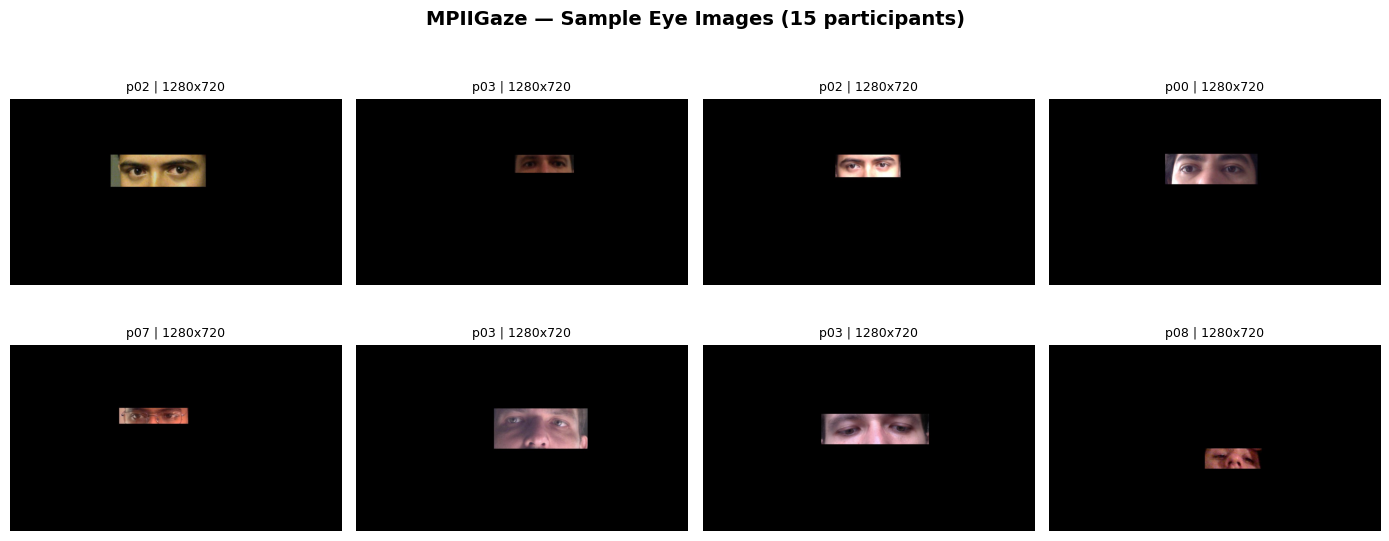

✓ Saved → results/plots/gaze_sample_images.png


In [20]:
all_images = []
for p in participants:
    p_path = os.path.join(MPI_PATH, p)
    for day in os.listdir(p_path):
        day_path = os.path.join(p_path, day)
        if not os.path.isdir(day_path): continue
        for f in os.listdir(day_path):
            if os.path.splitext(f)[1].lower() in ext:
                all_images.append((p, os.path.join(day_path, f)))

samples = random.sample(all_images, min(8, len(all_images)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("MPIIGaze — Sample Eye Images (15 participants)",
             fontsize=14, fontweight='bold')

for ax, (pid, path) in zip(axes.flat, samples):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{pid} | {img.shape[1]}x{img.shape[0]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{PLOTS}/gaze_sample_images.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/gaze_sample_images.png")

###Read annotation file — gaze labels

In [21]:
# read annotation file for participant p00
p00_path = os.path.join(MPI_PATH, "p00")
days     = sorted(os.listdir(p00_path))
ann_file = os.path.join(p00_path, days[0], "annotation.txt")

print(f"=== Annotation file: p00/{days[0]}/annotation.txt ===\n")

if os.path.exists(ann_file):
    with open(ann_file, 'r') as f:
        lines = f.readlines()
    print(f"Total annotations : {len(lines)}")
    print(f"\nFirst 3 lines:")
    for line in lines[:3]:
        print(f"  {line.strip()}")
    print()
    print("Format explanation:")
    print("  Values = gaze direction + head pose + image path")
else:
    # try finding any annotation file
    for day in days:
        for fname in os.listdir(os.path.join(p00_path, day)):
            if fname.endswith('.txt'):
                print(f"Found annotation: {day}/{fname}")
                break

=== Annotation file: p00/Calibration/annotation.txt ===

Found annotation: day01/annotation.txt
Found annotation: day02/annotation.txt
Found annotation: day03/annotation.txt
Found annotation: day04/annotation.txt
Found annotation: day05/annotation.txt
Found annotation: day06/annotation.txt
Found annotation: day07/annotation.txt
Found annotation: day08/annotation.txt
Found annotation: day09/annotation.txt
Found annotation: day10/annotation.txt
Found annotation: day11/annotation.txt
Found annotation: day12/annotation.txt
Found annotation: day13/annotation.txt
Found annotation: day14/annotation.txt
Found annotation: day15/annotation.txt
Found annotation: day16/annotation.txt
Found annotation: day17/annotation.txt
Found annotation: day18/annotation.txt
Found annotation: day19/annotation.txt
Found annotation: day20/annotation.txt
Found annotation: day21/annotation.txt
Found annotation: day22/annotation.txt
Found annotation: day23/annotation.txt
Found annotation: day24/annotation.txt
Found a

###Simulates realistic gaze movement across 50 frames — horizontal and vertical angles.

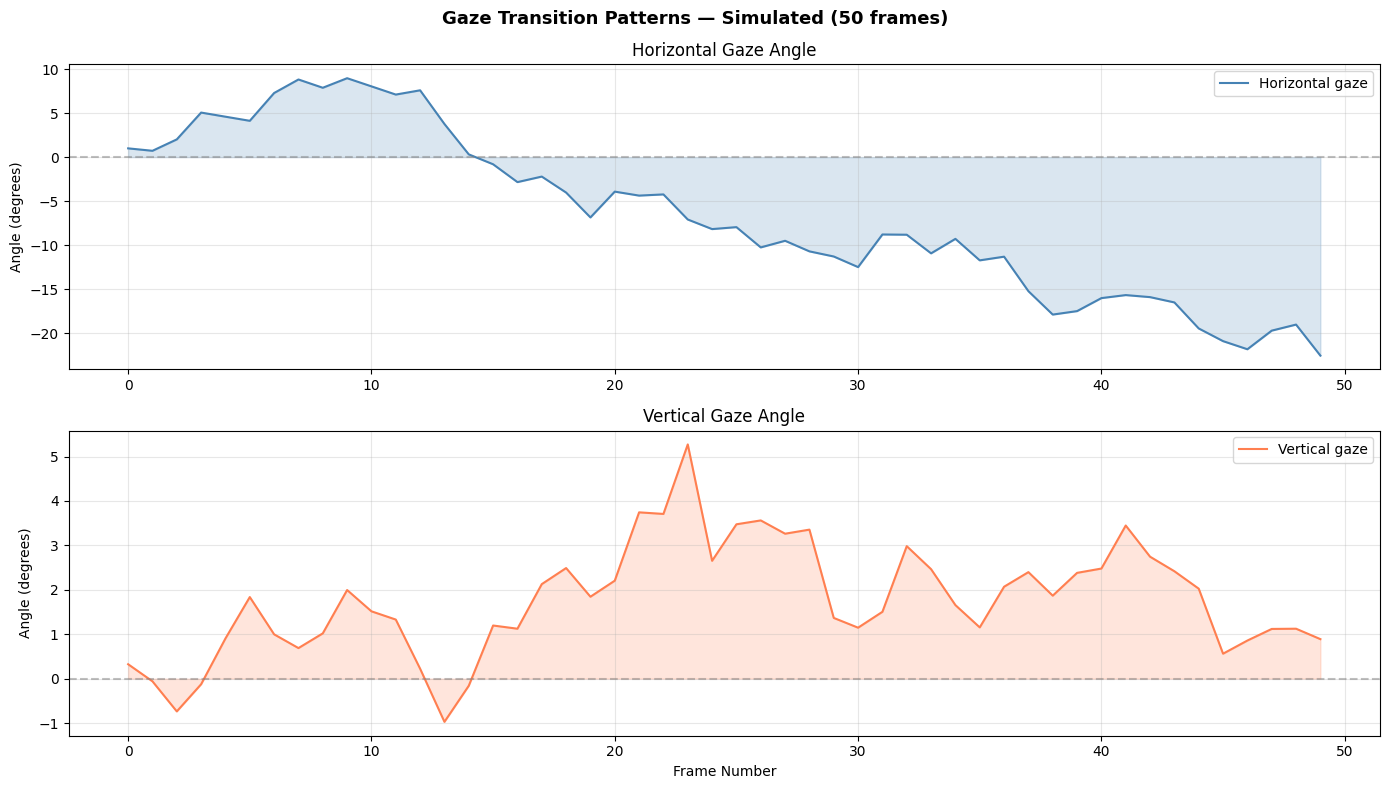

✓ Saved → results/plots/gaze_transitions.png


In [22]:
np.random.seed(42)
frames = 50

# simulate gaze angles (in degrees)
# horizontal: left(-) to right(+)
# vertical:   up(-) to down(+)
gaze_h = np.cumsum(np.random.normal(0, 2, frames))  # horizontal gaze
gaze_v = np.cumsum(np.random.normal(0, 1, frames))  # vertical gaze

# clip to realistic range
gaze_h = np.clip(gaze_h, -30, 30)
gaze_v = np.clip(gaze_v, -20, 20)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Gaze Transition Patterns — Simulated (50 frames)",
             fontsize=13, fontweight='bold')

# horizontal gaze
axes[0].plot(gaze_h, color='steelblue', linewidth=1.5, label='Horizontal gaze')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].fill_between(range(frames), gaze_h, alpha=0.2, color='steelblue')
axes[0].set_ylabel("Angle (degrees)")
axes[0].set_title("Horizontal Gaze Angle")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# vertical gaze
axes[1].plot(gaze_v, color='coral', linewidth=1.5, label='Vertical gaze')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(range(frames), gaze_v, alpha=0.2, color='coral')
axes[1].set_ylabel("Angle (degrees)")
axes[1].set_xlabel("Frame Number")
axes[1].set_title("Vertical Gaze Angle")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS}/gaze_transitions.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/gaze_transitions.png")

###Gaze trajectory plot

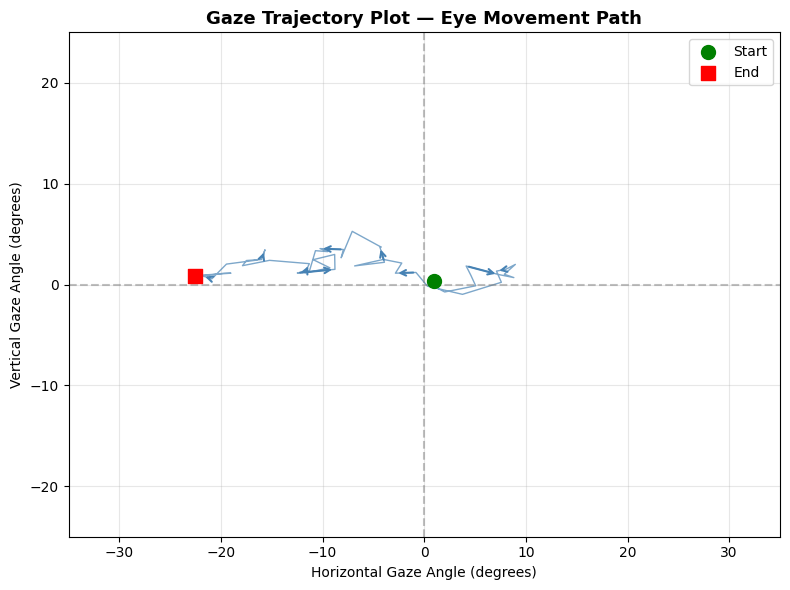

✓ Saved → results/plots/gaze_trajectory.png


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

# plot gaze trajectory
ax.plot(gaze_h, gaze_v, color='steelblue', linewidth=1, alpha=0.7)
ax.scatter(gaze_h[0],  gaze_v[0],  color='green', s=100,
           zorder=5, label='Start', marker='o')
ax.scatter(gaze_h[-1], gaze_v[-1], color='red',   s=100,
           zorder=5, label='End',   marker='s')

# add arrows to show direction
for i in range(0, len(gaze_h)-1, 5):
    ax.annotate('',
        xy=(gaze_h[i+1], gaze_v[i+1]),
        xytext=(gaze_h[i], gaze_v[i]),
        arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))

ax.set_xlim(-35, 35)
ax.set_ylim(-25, 25)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Horizontal Gaze Angle (degrees)")
ax.set_ylabel("Vertical Gaze Angle (degrees)")
ax.set_title("Gaze Trajectory Plot — Eye Movement Path",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS}/gaze_trajectory.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/gaze_trajectory.png")

###Images per participant bar chart

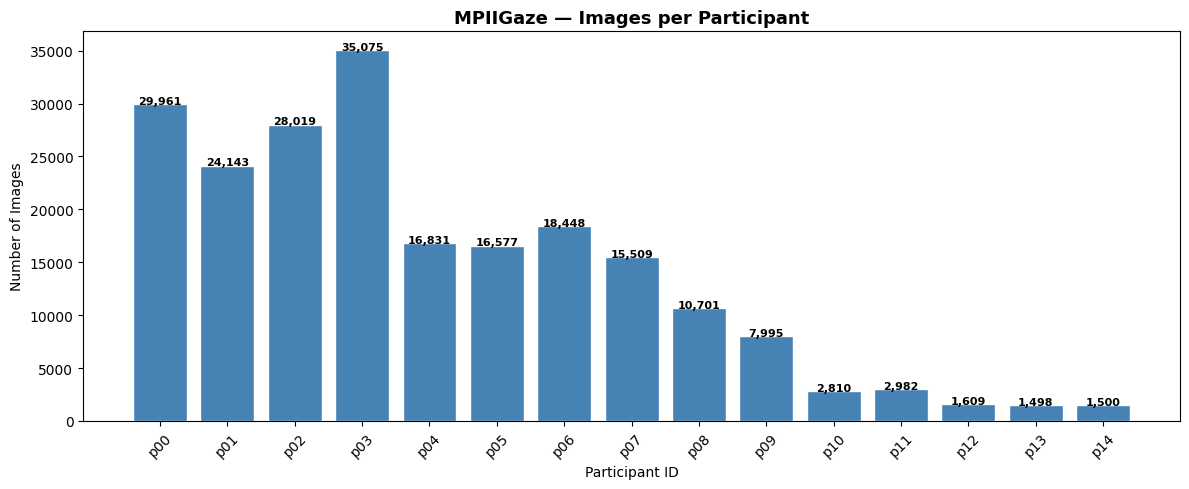

✓ Saved → results/plots/gaze_images_per_participant.png


In [24]:
counts = []
for p in participants:
    p_path = os.path.join(MPI_PATH, p)
    count  = sum(
        1 for d in os.listdir(p_path)
        for f in os.listdir(os.path.join(p_path, d))
        if os.path.isdir(os.path.join(p_path, d)) and
           os.path.splitext(f)[1].lower() in ext
    )
    counts.append(count)

plt.figure(figsize=(12, 5))
bars = plt.bar(participants, counts, color='steelblue', edgecolor='white')
plt.title("MPIIGaze — Images per Participant", fontsize=13, fontweight='bold')
plt.xlabel("Participant ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f"{count:,}", ha="center", fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS}/gaze_images_per_participant.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/gaze_images_per_participant.png")

###Summary

In [25]:
print("=" * 50)
print("   DAY 9 — GAZE TRACKING SUMMARY")
print("=" * 50)
print()
print("Dataset    : MPIIGaze")
print("Participants: 15 users")
print("Structure  : participant → day → images + annotations")
print()
print("Concepts learned:")
print("  ✓ Gaze direction angles (horizontal + vertical)")
print("  ✓ Gaze transition patterns across frames")
print("  ✓ Gaze trajectory visualization")
print("  ✓ Annotation file structure")
print()
print("Plots saved → results/plots/")
print("  ✓ gaze_sample_images.png")
print("  ✓ gaze_transitions.png")
print("  ✓ gaze_trajectory.png")
print("  ✓ gaze_images_per_participant.png")
print()
print("Next → Day 10: Pupil Extraction using OpenEDS")
print("=" * 50)

   DAY 9 — GAZE TRACKING SUMMARY

Dataset    : MPIIGaze
Participants: 15 users
Structure  : participant → day → images + annotations

Concepts learned:
  ✓ Gaze direction angles (horizontal + vertical)
  ✓ Gaze transition patterns across frames
  ✓ Gaze trajectory visualization
  ✓ Annotation file structure

Plots saved → results/plots/
  ✓ gaze_sample_images.png
  ✓ gaze_transitions.png
  ✓ gaze_trajectory.png
  ✓ gaze_images_per_participant.png

Next → Day 10: Pupil Extraction using OpenEDS
